In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns

In [ ]:
path = kagglehub.dataset_download("harishkumardatalab/housing-price-prediction")
houses_prices = pd.read_csv(path + '/Housing.csv')

100%|██████████| 4.63k/4.63k [00:00<00:00, 2.55MB/s]

Extracting files...


In [ ]:
houses_prices

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
houses_prices.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
houses_prices.mainroad = houses_prices.mainroad.map({'yes': 1, 'no': 0})

In [ ]:
houses_prices

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,1,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,1,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,1,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,1,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,0,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,1,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,0,no,no,no,no,0,no,furnished


In [ ]:
houses_prices.guestroom = houses_prices.guestroom.map({'yes': 1, 'no': 0})

In [ ]:
houses_prices.basement = houses_prices.basement.map({'yes': 1, 'no': 0})

In [ ]:
houses_prices.hotwaterheating = houses_prices.hotwaterheating.map({'yes': 1, 'no': 0})

In [ ]:
houses_prices.airconditioning = houses_prices.airconditioning.map({'yes': 1, 'no': 0})

In [ ]:
houses_prices.prefarea = houses_prices.prefarea.map({'yes': 1, 'no': 0})

In [ ]:
houses_prices.furnishingstatus.value_counts()

,count
furnishingstatus,
semi-furnished,227
unfurnished,178
furnished,140


In [ ]:
houses_prices.furnishingstatus = houses_prices.furnishingstatus.map({'unfurnished': 1, 'semi-furnished': 2, 'furnished': 3})

In [ ]:
houses_prices

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,3
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,3
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,3
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,2
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,3


## Outliers

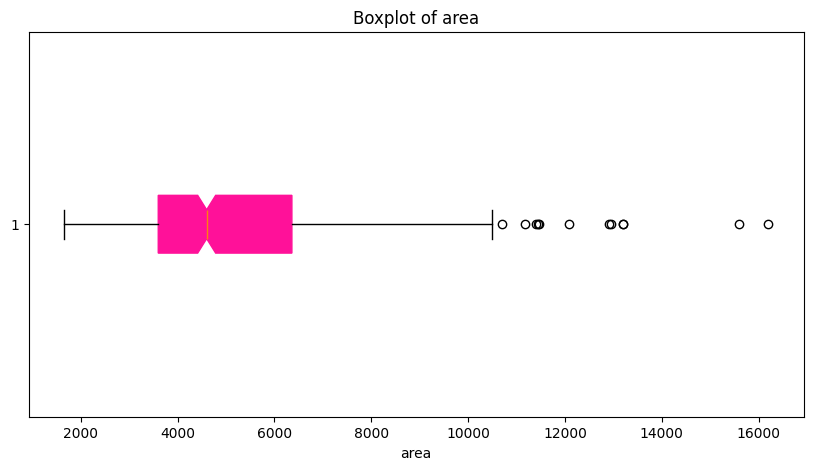

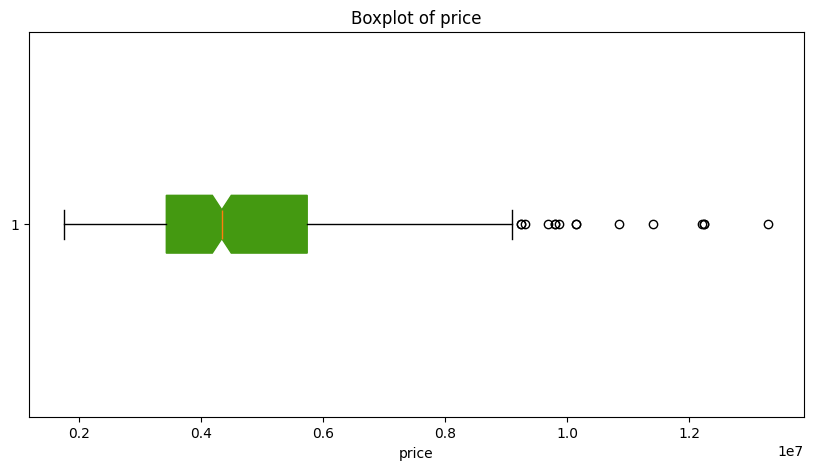

In [ ]:
colors = ['#ff1199', '#449911']
check_outliers = ['area', 'price']
for i, color in zip(check_outliers, colors):
  plt.figure(figsize=(10, 5))
  plt.boxplot(houses_prices[i], notch=True, vert=False, patch_artist=True, boxprops=dict(facecolor=color, color=color))
  plt.title(f'Boxplot of {i}')
  plt.xlabel(i)
  plt.show()

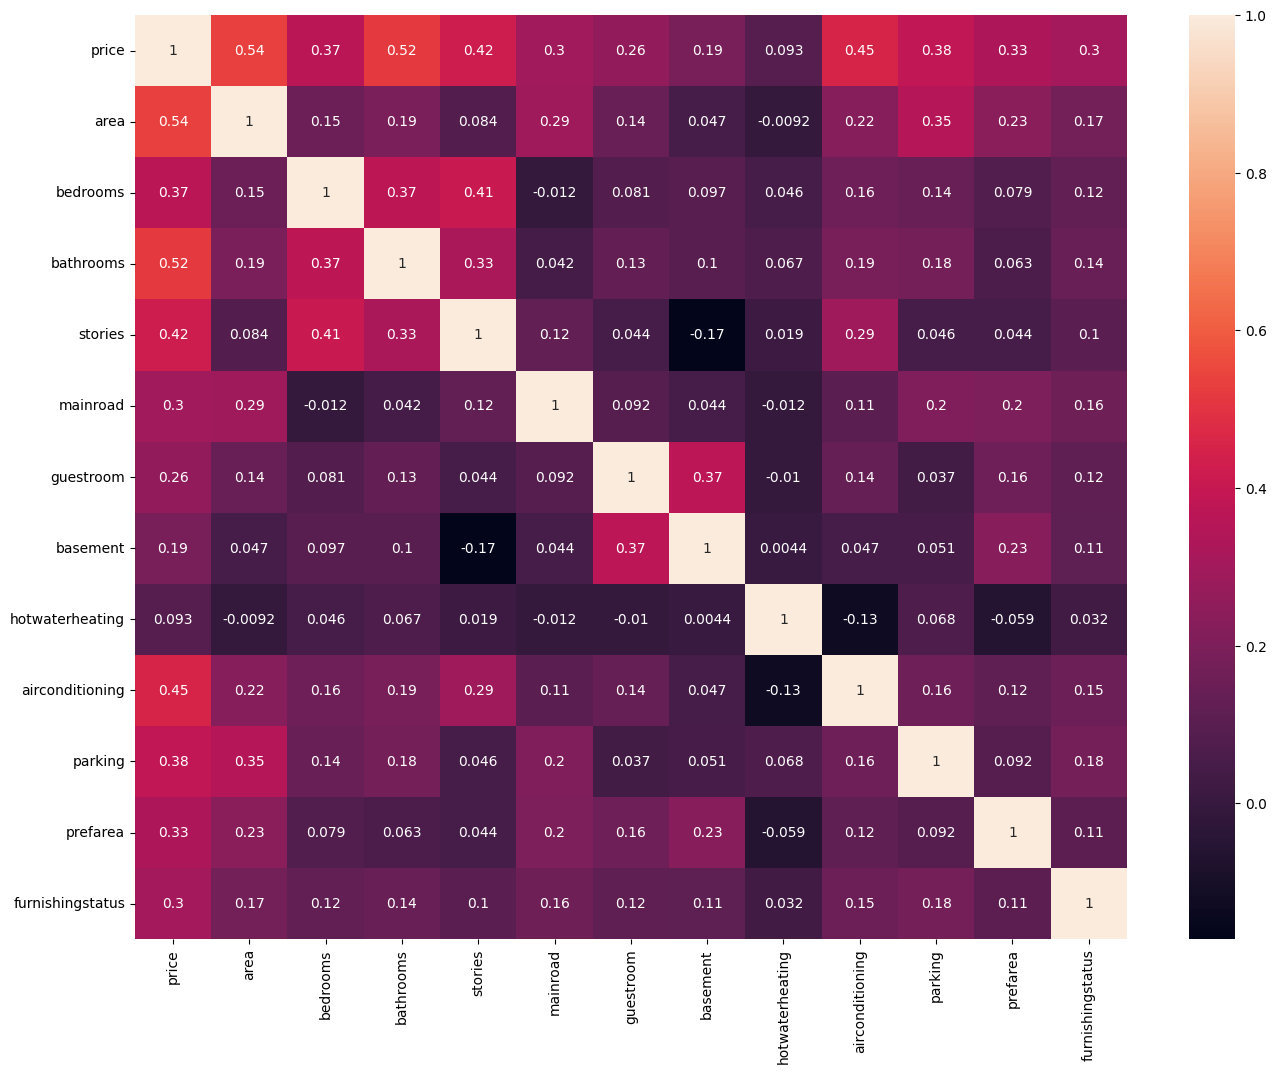

In [ ]:
corr_matrix = houses_prices.corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=True)
plt.show()

## Impartirea setului de date

In [ ]:
X = houses_prices.drop(columns=['price'])
y = houses_prices.price

In [ ]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,3
1,8960,4,4,4,1,0,0,0,1,3,0,3
2,9960,3,2,2,1,0,1,0,0,2,1,2
3,7500,4,2,2,1,0,1,0,1,3,1,3
4,7420,4,1,2,1,1,1,0,1,2,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,2
542,3620,2,1,1,1,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,3


In [ ]:
y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,1,0,0,0,1,1,0,3
93,7200,3,2,1,1,0,1,0,1,3,0,2
335,3816,2,1,1,1,0,1,0,1,2,0,3
412,2610,3,1,2,1,0,1,0,0,0,1,1
471,3750,3,1,2,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,1
106,5450,4,2,1,1,0,1,0,1,0,1,2
270,4500,3,2,3,1,0,0,1,0,1,0,3
435,4040,2,1,1,1,0,0,0,0,0,0,1


In [ ]:
y_train

,price
46,7525000
93,6300000
335,3920000
412,3430000
471,3010000
...,...
71,6755000
106,6160000
270,4340000
435,3290000


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

In [ ]:
X_train_scaled

array([[ 0.38416819,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  1.40940148],
       [ 0.9291807 ,  0.05527092,  1.53917323, ...,  2.70998729,
        -0.55262032,  0.07931697],
       [-0.60775457, -1.28351359, -0.5579503 , ...,  1.53897197,
        -0.55262032,  1.40940148],
       ...,
       [-0.29709744,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  1.40940148],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032, -1.25076755],
       [ 0.15707965,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  0.07931697]])

In [ ]:
y_train_scaled

array([[ 1.60509012],
       [ 0.90746568],
       [-0.44791897],
       [-0.72696874],
       [-0.96615427],
       [-0.04927642],
       [-1.68371084],
       [-0.96615427],
       [-1.24520405],
       [-0.56751173],
       [-0.57149815],
       [-1.2850683 ],
       [-0.28846195],
       [-0.60737598],
       [-0.60737598],
       [ 0.38524395],
       [-1.6739441 ],
       [ 0.30950186],
       [-0.68710449],
       [ 1.18651545],
       [-0.44791897],
       [-0.44791897],
       [ 0.6284159 ],
       [ 0.30950186],
       [ 0.7081444 ],
       [-0.68710449],
       [-1.30898685],
       [-1.16547554],
       [ 0.32943399],
       [-0.58744385],
       [-0.28846195],
       [-1.38472894],
       [-0.64724024],
       [-0.04927642],
       [-0.28846195],
       [-0.92230359],
       [-0.82662938],
       [ 2.36251095],
       [-0.60737598],
       [ 1.50144306],
       [-0.00941217],
       [-0.22866557],
       [-0.60737598],
       [-0.17285561],
       [-0.24859769],
       [-1

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
cross_val_scores = cross_val_score(model, X_train_scaled, y_train_scaled, cv=5, scoring='r2')
print(cross_val_scores)

[0.69805724 0.68361811 0.61059162 0.61799873 0.62446075]


In [ ]:
model.fit(X_train_scaled, y_train_scaled)

LinearRegression()

In [ ]:
X_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,5900,4,2,2,0,0,1,0,0,1,0,1
77,6500,3,2,3,1,0,0,0,1,0,1,3
360,4040,2,1,1,1,0,0,0,0,0,0,2
90,5000,3,1,2,1,0,0,0,1,0,0,2
493,3960,3,1,1,1,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,1,0,1,0,0,2,0,2
357,6930,4,1,2,0,0,0,0,0,1,0,3
39,6000,4,2,4,1,0,0,0,1,1,0,2
54,6000,3,2,2,1,1,0,0,1,1,0,2


In [ ]:
X_test_scale = scaler_X.transform(X_test)

In [ ]:
X_test_scale

array([[ 0.33875048,  1.39405543,  1.53917323, ...,  0.36795665,
        -0.55262032, -1.25076755],
       [ 0.61125674,  0.05527092,  1.53917323, ..., -0.80305867,
         1.80956067,  1.40940148],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.80305867,
        -0.55262032,  0.07931697],
       ...,
       [ 0.38416819,  1.39405543,  1.53917323, ...,  0.36795665,
        -0.55262032,  0.07931697],
       [ 0.38416819,  0.05527092,  1.53917323, ...,  0.36795665,
        -0.55262032,  0.07931697],
       [ 0.4295859 ,  0.05527092,  1.53917323, ...,  1.53897197,
         1.80956067,  1.40940148]])

In [ ]:
y_pred = model.predict(X_test_scale)

In [ ]:
y_pred

array([[ 0.28312979],
       [ 1.45246927],
       [-0.93606895],
       [-0.08367833],
       [-0.78224776],
       [-0.65118072],
       [ 0.53471571],
       [ 0.97237588],
       [-1.11090049],
       [-1.16038507],
       [ 2.7700377 ],
       [-1.07012508],
       [-0.86040792],
       [-0.77123857],
       [-0.56530239],
       [ 0.33859607],
       [-0.97872844],
       [ 0.05938204],
       [-0.18422734],
       [-0.67281476],
       [ 0.62059083],
       [ 0.64550098],
       [-1.10840439],
       [ 0.03192715],
       [ 0.28373574],
       [ 1.5997043 ],
       [-0.82681065],
       [ 0.30162267],
       [ 1.9772646 ],
       [-0.72459616],
       [ 0.98942749],
       [-0.77480313],
       [ 1.1593649 ],
       [-0.31412494],
       [-0.63633311],
       [ 0.61595884],
       [ 0.03521881],
       [-0.17929993],
       [-0.84789579],
       [-0.03891364],
       [-0.1049951 ],
       [-0.66359366],
       [ 1.4417242 ],
       [-0.39010686],
       [-0.57207973],
       [-0

In [ ]:
y_test

,price
316,4060000
77,6650000
360,3710000
90,6440000
493,2800000
...,...
15,9100000
357,3773000
39,7910000
54,7350000


In [ ]:
y_pred_scale = scaler_y.inverse_transform(y_pred)

In [ ]:
y_pred_scale

array([[5203691.70963177],
       [7257004.02115475],
       [3062828.59668172],
       [4559591.65374424],
       [3332932.30559783],
       [3563080.67918996],
       [5645466.3121997 ],
       [6413979.66873635],
       [2755831.54819001],
       [2668938.6607523 ],
       [9570600.29915351],
       [2827431.50860063],
       [3195686.25834091],
       [3352263.99438472],
       [3713879.49996132],
       [5301088.2443575 ],
       [2987920.26669682],
       [4810799.8212371 ],
       [4383031.70489929],
       [3525092.18938646],
       [5796259.50068012],
       [5840000.702993  ],
       [2760214.60864101],
       [4762590.14920608],
       [5204755.73895204],
       [7515542.71619022],
       [3254681.68956383],
       [5236164.45964445],
       [8178523.16820279],
       [3434166.1567565 ],
       [6443921.58767582],
       [3346004.77919185],
       [6742324.74004132],
       [4154936.84088665],
       [3589152.47491253],
       [5788125.92515323],
       [4768370.18154077],
 

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_scale)

In [ ]:
r2

0.6494754192267791

## SGDRegressor

In [ ]:
from sklearn.linear_model import SGDRegressor
grad_regressor = SGDRegressor(max_iter=500, eta0=0.001, learning_rate='constant', tol=1e-5)

In [ ]:
grad_regressor.fit(X_train_scaled, y_train_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor(eta0=0.001, learning_rate='constant', max_iter=500, tol=1e-05)

In [ ]:
y_pred_regressor = grad_regressor.predict(X_test_scale)

In [ ]:
y_pred_regressor

array([ 0.2709326 ,  1.4515624 , -0.93350286, -0.08085167, -0.7752532 ,
       -0.64616352,  0.54048834,  0.97759184, -1.10906203, -1.15676637,
        2.75909551, -1.06805076, -0.85908831, -0.78075752, -0.57184227,
        0.33173834, -0.98174402,  0.0600131 , -0.19272989, -0.6709041 ,
        0.61661584,  0.6586916 , -1.10623476,  0.03503334,  0.27855368,
        1.59152528, -0.82600365,  0.29736963,  1.97525549, -0.72741894,
        0.98888045, -0.77617993,  1.15702857, -0.31480927, -0.63305483,
        0.61383005,  0.03097537, -0.17873016, -0.8426214 , -0.03767138,
       -0.10254005, -0.65844673,  1.44084409, -0.3907904 , -0.57041988,
       -0.22909225,  1.12432049, -0.40356393, -0.51659336, -0.72103576,
        1.45605719, -1.06595517, -0.18618329, -0.14285335, -0.56743347,
       -1.12863079,  1.60013165, -0.99987671, -0.28829395, -1.08600394,
        0.04446794, -0.62703945,  0.22007606, -0.26256724,  0.01614709,
       -0.05174316,  1.40876821, -0.70180186,  0.68446652,  0.88

In [ ]:
y_pred_regressor = scaler_y.inverse_transform(y_pred_regressor.reshape(1, -1))

In [ ]:
y_pred_regressor

array([[5182273.94403332, 7255411.60625061, 3067334.53694659,
        4564555.16753716, 3345214.47193107, 3571890.66732998,
        5655602.8120699 , 6423138.6778516 , 2759059.81368319,
        2675292.94857012, 9551386.27031802, 2831073.93682049,
        3198003.45158399, 3335549.11435712, 3702395.75079355,
        5289046.33551238, 2982625.02783381, 4811907.93424299,
        4368101.5753085 , 3528447.220485  , 5789279.58775269,
        5863162.89246054, 2764024.38844884, 4768044.49466253,
        5195656.25781929, 7501180.6867133 , 3256098.76152151,
        5228696.29809081, 8174995.24620669, 3429209.474431  ,
        6442961.00909065, 3343587.1708076 , 6738222.24102621,
        4153735.17578807, 3594908.99515431, 5784387.84874836,
        4760918.86427148, 4392684.52794047, 3226918.66148774,
        4640377.97796146, 4526471.25663848, 3550321.8510792 ,
        7236590.6803919 , 4020315.4166268 , 3704893.40041042,
        4304250.76555686, 6680788.18500923, 3997885.62296629,
        

In [ ]:
r2 = r2_score(y_test, y_pred_regressor[0])

In [ ]:
r2

0.6493979956974204

## Analiza reziduurilor

In [ ]:
residuals = y_test - y_pred_regressor[0]

In [ ]:
residuals

,price
316,-1.122274e+06
77,-6.054116e+05
360,6.426655e+05
90,1.875445e+06
493,-5.452145e+05
...,...
15,4.176494e+06
357,-6.014656e+05
39,9.204198e+05
54,9.949107e+05


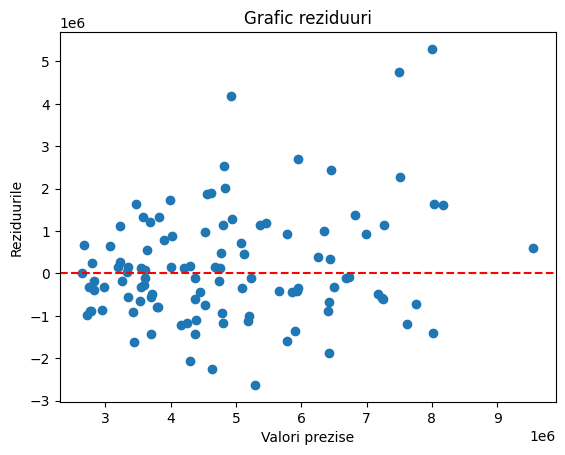

In [ ]:
plt.scatter(y_pred_regressor[0], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valori prezise')
plt.ylabel('Reziduurile')
plt.title('Grafic reziduuri')
plt.show()

In [ ]:
np.mean(residuals)

np.float64(142673.54378863177)

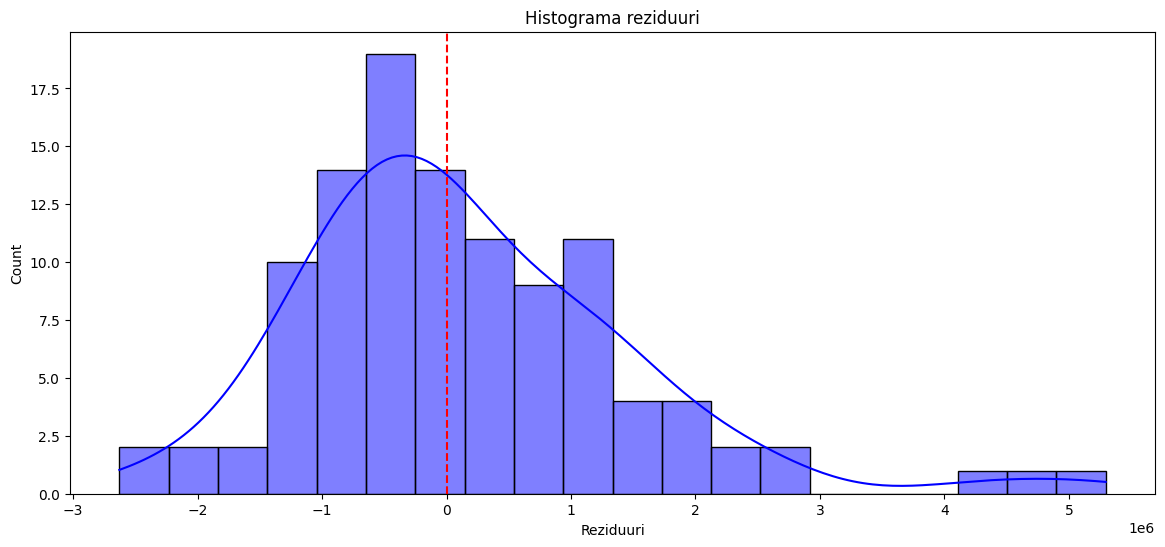

In [ ]:
plt.figure(figsize=(14,6))
sns.histplot(residuals, kde=True, bins=20, color='blue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Reziduuri')
plt.title('Histograma reziduuri')
plt.show()